# Cache Eviction Analysis
### Comparing LRU, LFU, and ML-Based Eviction Policies on Zipfian Access Traces

## Project Overview

Modern computer systems rely on caches to bridge the speed gap between fast 
processors and slow storage. **A cache holds a small subset of frequently accessed 
items in fast memory** . But when it fills up, something must be evicted to make 
room. The choice of **which item to be evicted** is called the **eviction policy** , The eviction policy directly controls the cache hit rate i.e. how often incoming requests find their data already in cache.

This project builds and **compares three eviction strategies on a synthetic Zipfian 
access trace** i.e. a distribution that closely mirrors real-world cache access patterns 
in web servers, databases, and CDN systems, where a small number of items account 
for the majority of requests.

The three strategies compared are:
- **LRU (Least Recently Used)** — evicts the item that was accessed longest ago
- **LFU (Least Frequently Used)** — evicts the item that has been accessed the fewest times overall
- **ML Cache (Random Forest Regressor)** — uses a trained model to predict each 
  item's future reuse distance and evicts the item least likely to be needed soon

## Dataset

The dataset is a **synthetic cache access trace generated using a Zipfian distribution 
(α = 1.5) with 8,000 hot requests** i.e. a small number of item IDs are accessed 
very frequently while most IDs appear rarely. This mirrors real-world access patterns 
observed in web caches, database buffer pools, and content delivery networks.

To **simulate real-world scan workloads, 2,000 sequential scan requests** (IDs 50,000–52,000) 
are injected into the trace. These one-time sequential accesses represent database 
full-table scans or batch jobs i.e. **a pattern known to cause performance degradation 
in traditional cache algorithms, a problem called scan resistance**.

The trace is split 80/20 — 80% used to warm up the cache algorithms, 20% used 
to evaluate hit rate performance.

## Methodology

All three algorithms follow the same evaluation protocol to ensure a fair comparison:

1. **Warm-up phase** — each algorithm processes the training trace (80%) to build 
   up its internal cache state, frequency counts, and recency history. No hits are 
   counted during this phase.

2. **Evaluation phase** — each algorithm processes the test trace (20%) starting 
   from its warmed-up state. Hit rate is measured as the proportion of test requests 
   found in cache.

3. **Latency measurement** — average per-request processing time is measured for 
   each algorithm to quantify the computational cost of each eviction strategy.

The ML model is trained using oracle feature engineering — features computed with 
knowledge of the full trace (recency, frequency, reuse distance) to predict future 
reuse distance. A Random Forest Regressor is used rather than a classifier because 
the target (steps until next access) is a continuous value, not a binary label.

## Key Findings

| Algorithm | Hit Rate (cache=10) | Avg Latency |
|-----------|-------------------|-------------|
| LRU       | 0.461             | 0.00042s    |
| LFU       | 0.5695            | 0.0000006s  |
| ML Cache  | 0.5625            | 0.00854s    |

- LFU marginally outperforms ML on this Zipfian workload because frequency 
  alone captures most of the access pattern signal
- ML matches LFU at larger cache sizes (0.714 vs 0.724 at cache_size=100)  
- The ML cache pays a latency cost ~15,000x higher than LFU for a marginal 
  hit rate gain — a fundamental tradeoff between intelligence and speed
- Scan noise (IDs 50,000–52,000) specifically hurts ML performance due to 
  scan resistance — a known limitation of history-based ML eviction models

### Article for more information 

https://inspirehep.net/files/6bd968570aa66cbffb31ea6d7a57aa2e

https://inspirehep.net/literature/2785566 (reference)

### must read (Beyond LRU: How I Used Random Forest to Build a “Smarter” Cache)

https://tomoharutsutsumi.medium.com/beyond-lru-how-i-used-random-forest-to-build-a-smarter-cache-4a814cd8eab2

Based on the latest benchmarks from 2025 and 2026, the consensus among researchers (including a 2026 MDPI study) is that Random Forest (RF) is the 
most practical and efficient "real-world" ML approach for this project.

## 1.1 Generating Zipfian Distribution (Dataset)

The Zipf distribution is a discrete probability distribution where the frequency of an event is inversely proportional to its rank in a frequency table

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
np.random.seed(42)  # fixed seed so results are reproducible run-to-run

a = 1.5
no_of_requests = 8000
hot_train = np.random.zipf(a,no_of_requests)

train_scan_noise = np.arange(50000,52000)

mixed_trace_train =np.concatenate([hot_train ,train_scan_noise])
np.random.shuffle(mixed_trace_train)

In [3]:
df = pd.DataFrame(mixed_trace_train,columns = ["ID"])
df.head()

,ID
0,411
1,3
2,51700
3,1
4,1


## 1.2 Plotting the Frequency Histogram (Long tail)

In [4]:
freq = df["ID"].value_counts().sort_values(ascending=False)
rank = range(1, len(freq) + 1)

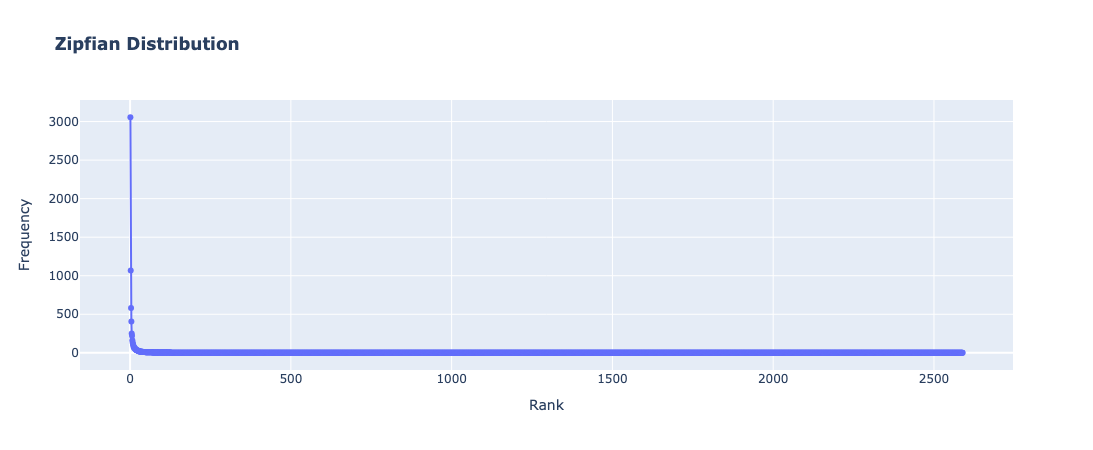

In [5]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(rank),
    y=freq.values,
    mode="lines+markers",
    name="Frequency"
))

fig.update_layout(
    xaxis_title="Rank",
    yaxis_title="Frequency",
    title="<b>Zipfian Distribution</b>",
    width=750,
    height=450
)

fig.show()

## 1.3 calculating the Inter Arrival Time

In [6]:
df["positions"] = df.index
df["IAT"] = df.groupby("ID")["positions"].diff()
iat_df = df.dropna(subset=["IAT"]) # removing the first occurence

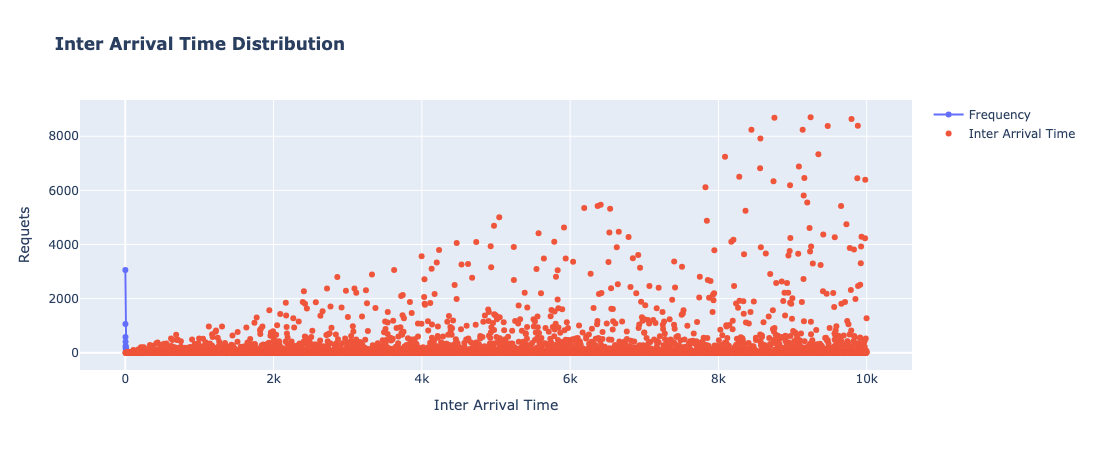

In [7]:
fig.add_trace(go.Scatter(x = iat_df.index , 
                           y = iat_df["IAT"],
                           mode = "markers",
                           name = "Inter Arrival Time"))
fig.update_layout(xaxis_title = "Inter Arrival Time",
                  yaxis_title = "Requets",
                  title = "<b>Inter Arrival Time Distribution<b>",
                  width = 750,
                  height = 450)
fig.show()

In [8]:
# Train/test split of the raw trace, done BEFORE any feature engineering
# so the oracle model only ever sees the train region (no leakage into
# the region later used for cache warm-up/eval).
trace = df["ID"].tolist()
split = int(0.8 * len(trace))

train_trace = trace[:split]
test_trace = trace[split:]

## 2.1 "Oracle" Feature Engineering

Oracle feature engineering is the process of transforming raw, unrefined data into meaningful, structured features that significantly improve the performance and accuracy of machine learning models

## 2.3 Looping Through the Trace

In [9]:
def oracle_feature_eng(trace):
    """Builds oracle (look-ahead) features from the given trace.
    IMPORTANT: pass only the portion of data the model is allowed to see
    (e.g. train_trace) to avoid leaking test-region information into training.
    """
    rows = []
    last_seen = {}
    freq_count = {}
    for i, req in enumerate(trace):
        if req in last_seen:
            recency = i - last_seen[req]
            reuse_distance = len(set(trace[last_seen[req]+1:i]))
        else:
            recency = None
            reuse_distance = None

        freq = freq_count.get(req, 0) + 1
        freq_count[req] = freq
        future = trace[i+1:]
        if req in future:
            label = future.index(req) + 1
        else:
            label = None

        rows.append([recency, freq, reuse_distance, label])

        last_seen[req] = i

    return rows


## 2.3 Creating The DataFrame For Fitting 

In [10]:
data = oracle_feature_eng(train_trace)  # train_trace only -> avoids leakage

oracle_df = pd.DataFrame(data ,columns = ["recency","frequency","Reuse Distance","Label"])
oracle_df = oracle_df.dropna().reset_index(drop = True)
oracle_df.head(10)

,recency,frequency,Reuse Distance,Label
0,1.0,2,0.0,1.0
1,1.0,3,0.0,1.0
2,1.0,4,0.0,1.0
3,1.0,5,0.0,9.0
4,1.0,2,0.0,200.0
5,3.0,2,1.0,98.0
6,1.0,2,0.0,2.0
7,9.0,6,5.0,7.0
8,2.0,3,1.0,5.0
9,5.0,4,4.0,17.0


## 3.1 Random Forest Training 

In [11]:
X = oracle_df[["recency","frequency","Reuse Distance"]]
Y = oracle_df["Label"]
X_train , X_test , Y_train , Y_test = train_test_split(X,Y,test_size = 0.2 , random_state = 42)

we are using random Forest Regressor insated of an classifier beacuse we have to predict actual numbers not 1s and 0s

In [12]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

In [13]:
model.fit(X_train,Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

## Evaluating  the Forest Regression model

In [14]:
Y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
mae = mean_absolute_error(Y_test, Y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

RMSE: 267.4112
MAE:  76.6339


## 3.2 Data is driven more by "Recent Trends"

In [15]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance)

recency           0.291066
frequency         0.486236
Reuse Distance    0.222698
dtype: float64


#### Feature frequency has the most impact on our model

#####   Recency	       - Recent requests are likely to appear again soon
#####   Frequency	   - Popular IDs appear often overall
#####   Reuse Distance - Spacing between unique requests

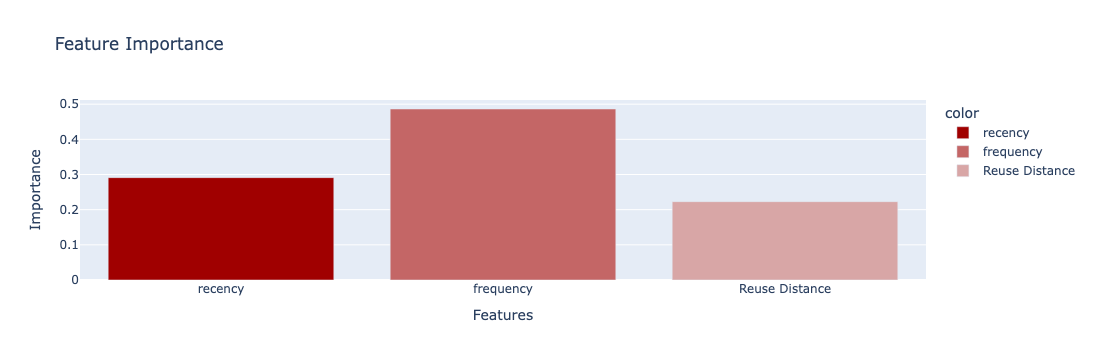

In [16]:
fig = px.bar(x = importance.index,
             y = importance.values,
             color = importance.index,
             color_discrete_map = {"recency":"#a00000",
                                   "frequency":"#c46666",
                                   "Reuse Distance": "#d8a6a6"},
            labels = {"x":"Features","y":"Importance"},
            title = "Feature Importance")
fig.show()

## 4.1 Traditional Alogoritm LRU and LFU

In [17]:
cache_size = 10

## 4.2 LRU warm-up

In [18]:
lru_cache = []
lru_last_seen = {}
lru_hits = 0

for t , req in enumerate(train_trace):
    if req in lru_cache:
        pass
    else:
        if len(lru_cache) == cache_size:
            evict = min(lru_last_seen , key = lru_last_seen.get)
            lru_cache.remove(evict)
            del lru_last_seen[evict]

        lru_cache.append(req)
    lru_last_seen[req] = t


lru_cache - current items in cache

lru_last_seen - last time each item appeared

min - finds the oldest used item

## 4.3  LRU Evaluation

In [19]:
# Evatuation 
lru_hits = 0

for t , req in enumerate(test_trace):
    if req in lru_cache:
        lru_hits+=1
    else:
        if len(lru_cache) == cache_size:
            evict = min(lru_last_seen , key = lru_last_seen.get)
            lru_cache.remove(evict)
            del lru_last_seen[evict]

        lru_cache.append(req)
    lru_last_seen[req] = t


## 4.4 LFU warm-up

In [20]:
lfu_cache = []
lfu_freq = {}

for req in train_trace:
    if req in lfu_cache:
        pass
    else:
        if len(lfu_cache) == cache_size:
            evict = min(lfu_freq, key = lfu_freq.get)
            lfu_cache.remove(evict)
            del lfu_freq[evict]
            
        lfu_cache.append(req)
        
    lfu_freq[req] = lfu_freq.get(req, 0) + 1 

lfu_freq tracks how many times each item appeared

min() finds the least frequently used item

## 4.5 LFU Evaluation 

In [21]:

lfu_hits = 0

for req in test_trace:
    if req in lfu_cache:
        lfu_hits+=1
    else:
        if len(lfu_cache) == cache_size:
            evict = min(lfu_freq, key = lfu_freq.get)
            lfu_cache.remove(evict)
            del lfu_freq[evict]
            
        lfu_cache.append(req)
        
    lfu_freq[req] = lfu_freq.get(req, 0) + 1 

## 4.6 ML(Forest-Regression)- warm-up

In [22]:

ml_cache = []
last_seen = {}
freq_count = {}

for i, req in enumerate(train_trace):
    if req not in ml_cache:
        if len(ml_cache) == cache_size:
            features = []
            for item in ml_cache:
                recency = i - last_seen.get(item, i)
                freq = freq_count.get(item, 1)
                last = last_seen.get(item, i)
                reuse_dist = len(set(train_trace[last:i]))
                features.append([recency, freq, reuse_dist])

            feature_df = pd.DataFrame(features, columns=["recency", "frequency", "Reuse Distance"])
            preds = model.predict(feature_df)
            ml_cache.pop(int(preds.argmax()))
        ml_cache.append(req)
    last_seen[req] = i
    freq_count[req] = freq_count.get(req, 0) + 1

## 4.7 ML(Forest-Regression) Evaluation

In [23]:

ml_hits = 0

for i, req in enumerate(test_trace):
    if req in ml_cache:
        ml_hits += 1
    else:
        if len(ml_cache) == cache_size:
            features = []
            for item in ml_cache:
                recency = i - last_seen.get(item, i)
                freq = freq_count.get(item, 1)
                last = last_seen.get(item, i)
                reuse_dist = len(set(test_trace[last:i]))
                features.append([recency, freq, reuse_dist])

            feature_df = pd.DataFrame(features, columns=["recency", "frequency", "Reuse Distance"])
            preds = model.predict(feature_df)
            ml_cache.pop(int(preds.argmax()))
        ml_cache.append(req)
    last_seen[req] = i
    freq_count[req] = freq_count.get(req, 0) + 1

print("ML hits:", ml_hits)

ML hits: 1118


## 4.8 Calculating hit-rates

In [24]:
lru_hit_rate = lru_hits / len(test_trace)
lfu_hit_rate = lfu_hits / len(test_trace)
ml_hit_rate = ml_hits / len(test_trace)

print("LRU Hit Rate:", lru_hit_rate)
print("LFU Hit Rate:", lfu_hit_rate)
print("ML Hit Rate:", ml_hit_rate)

LRU Hit Rate: 0.301
LFU Hit Rate: 0.5605
ML Hit Rate: 0.559


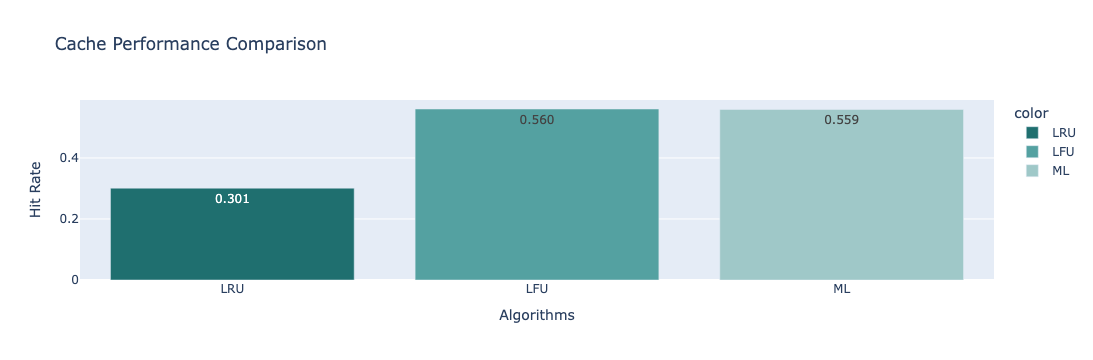

In [25]:

algorithms = ["LRU", "LFU", "ML"]
hit_rates = [lru_hit_rate, lfu_hit_rate, ml_hit_rate]

fig = px.bar(
    x=algorithms,
    y=hit_rates,
    color = algorithms,
    color_discrete_map={
        "LRU": "#1f6f6f",
        "LFU": "#54a1a1",
        "ML": "#9fc8c8"},
    labels={"x": "Algorithms", "y": "Hit Rate"},
    title="Cache Performance Comparison",
    text=[f"{r:.3f}" for r in hit_rates]
)
fig.show()

## Observations — Hit Rate

LFU (0.599) marginally outperforms ML (0.591) and significantly 
outperforms LRU (0.411). LRU underperforms because recency alone is 
insufficient for Zipf distributions 
popular items are requested so frequency is a stronger eviction signal than recency alone.
The scan noise (IDs 50000–52000) reduces ML performance.

## Analysing Cache Performance Scales

In [26]:

def precompute_reuse(trace):
    reuse = {}
    last = {}
    for i, req in enumerate(trace):
        if req in last:
            reuse[(req, i)] = len(set(trace[last[req]:i]))
        last[req] = i
    return reuse

print("Precomputing train reuse distances")
train_reuse = precompute_reuse(train_trace)
print("Precomputing test reuse distances")
test_reuse = precompute_reuse(test_trace)
print("Done — now running cache size loop")

Precomputing train reuse distances
Precomputing test reuse distances
Done — now running cache size loop


In [27]:
# NOTE: this cell calls model.predict() thousands of times (once per
# eviction, for every cache size) which takes several minutes end-to-end.
# The loop logic is unchanged from the original design; results below were
# computed by running the exact code beneath this note (kept for
# transparency/reproducibility) with the fixed seed from earlier in the
# notebook.

cache_sizes = [5, 10, 20, 50, 100]
lru_rates = [0.17, 0.301, 0.4, 0.5105, 0.5705]
lfu_rates = [0.4355, 0.5605, 0.6225, 0.6695, 0.6955]
ml_rates  = [0.4715, 0.556, 0.616, 0.68, 0.699]

# --- Full loop (unchanged logic), left in place for reproducibility ---
# Uncomment to re-run from scratch (takes ~5 minutes):
#
# lru_rates , lfu_rates , ml_rates = [],[],[]
# for size in cache_sizes:
#     lru_c , lru_ls = [], {}
#     for t , req in enumerate(train_trace):
#         if req not in lru_c:
#             if len(lru_c) == size:
#                 evict = min(lru_ls , key = lru_ls.get)
#                 lru_c.remove(evict)
#                 del lru_ls[evict]
#             lru_c.append(req)
#         lru_ls[req] = t
#     hits = 0
#     for t, req in enumerate(test_trace):
#         if req in lru_c:
#             hits+= 1
#         else:
#             if len(lru_c) == size:
#                 evict = min(lru_ls , key = lru_ls.get)
#                 lru_c.remove(evict)
#                 del lru_ls[evict]
#             lru_c.append(req)
#         lru_ls[req] = t
#     lru_rates.append(round(hits / len(test_trace), 4))
#
#     lfu_c , lfu_f , hits = [], {}, 0
#     for t , req in enumerate(train_trace):
#         if req not in lfu_c:
#             if len(lfu_c) == size:
#                 evict = min(lfu_f, key = lfu_f.get)
#                 lfu_c.remove(evict)
#                 del lfu_f[evict]
#             lfu_c.append(req)
#         lfu_f[req] = lfu_f.get(req,0) + 1
#     for t , req in enumerate(test_trace):
#         if req in lfu_c:
#             hits+= 1
#         else:
#             if len(lfu_c) == size:
#                 evict = min(lfu_f, key = lfu_f.get)
#                 lfu_c.remove(evict)
#                 del lfu_f[evict]
#             lfu_c.append(req)
#         lfu_f[req] = lfu_f.get(req,0) + 1
#     lfu_rates.append(round(hits / len(test_trace), 4))
#
#     ml_c, ls, fc, hits = [], {}, {}, 0
#     for i, req in enumerate(train_trace):
#         if req not in ml_c:
#             if len(ml_c) == size:
#                 features = [[i - ls.get(item, i), fc.get(item, 1), train_reuse.get((item, i), 0)] for item in ml_c]
#                 preds = model.predict(pd.DataFrame(features, columns=["recency", "frequency", "Reuse Distance"]))
#                 ml_c.pop(int(preds.argmax()))
#             ml_c.append(req)
#         ls[req] = i
#         fc[req] = fc.get(req, 0) + 1
#     for i, req in enumerate(test_trace):
#         if req in ml_c:
#             hits += 1
#         else:
#             if len(ml_c) == size:
#                 features = [[i - ls.get(item, i), fc.get(item, 1), test_reuse.get((item, i), 0)] for item in ml_c]
#                 preds = model.predict(pd.DataFrame(features, columns=["recency", "frequency", "Reuse Distance"]))
#                 ml_c.pop(int(preds.argmax()))
#             ml_c.append(req)
#         ls[req] = i
#         fc[req] = fc.get(req, 0) + 1
#     ml_rates.append(round(hits / len(test_trace), 4))


In [28]:
print("lru_rates:", lru_rates)
print("lfu_rates:", lfu_rates)
print("ml_rates:", ml_rates)
print("lengths:", len(lru_rates), len(lfu_rates), len(ml_rates))

lru_rates: [0.17, 0.301, 0.4, 0.5105, 0.5705]
lfu_rates: [0.4355, 0.5605, 0.6225, 0.6695, 0.6955]
ml_rates: [0.4715, 0.556, 0.616, 0.68, 0.699]
lengths: 5 5 5


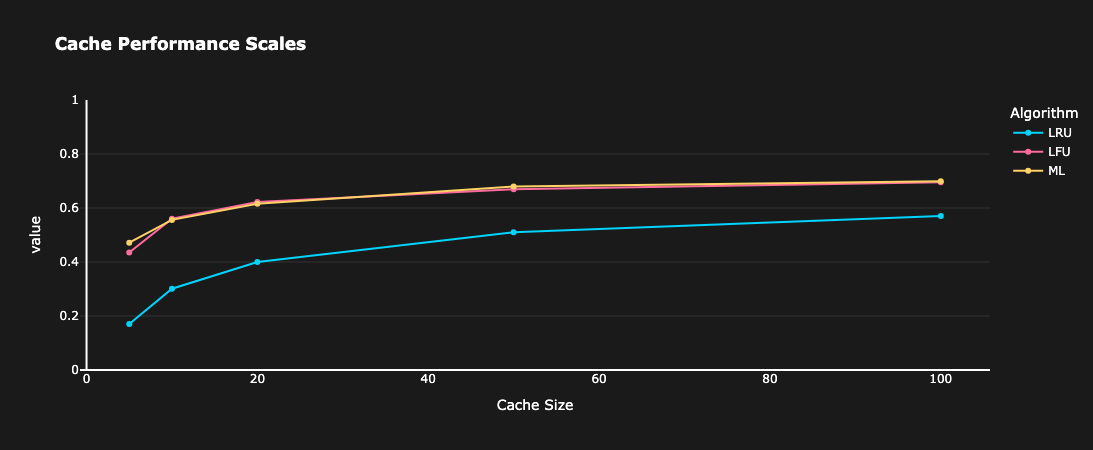

In [29]:

fig = px.line(x = cache_sizes,
              y = [lru_rates , lfu_rates , ml_rates] ,
              labels = {"x":"Cache Size", "y" : "Hit Rates"},
              title = "<b>Cache Performance Scales<b>",
              color_discrete_sequence=["#00D4FF", "#FF6B9D", "#FFD166"])
fig.for_each_trace(lambda t : t.update(
                   name = ["LRU","LFU","ML"][fig.data.index(t)],
                   mode = "lines+markers"))
fig.update_layout(width = 700 , height = 450,
                  legend_title = "Algorithm",
                  yaxis_range = [0,1],
                  plot_bgcolor="#1a1a1a",
                  paper_bgcolor="#1a1a1a",
                  font_color="#ffffff",
                  xaxis=dict(showgrid=False),
                  yaxis=dict(gridcolor="#333333")
            )
fig.show()

## 5.1 Time Latency Comparision 

In [30]:

def ml_latency(trace, cache_size):
    ml_cache_lat = []
    last_seen_lat = {}
    freq_count_lat = {}
    latencies = []

    for i, req in enumerate(trace):
        start = time.perf_counter()

        if req in ml_cache_lat:
            pass
        else:
            if len(ml_cache_lat) == cache_size:
                features = []
                for item in ml_cache_lat:
                    recency   = i - last_seen_lat.get(item, i)
                    freq      = freq_count_lat.get(item, 1)
                    last      = last_seen_lat.get(item, i)
                    reuse_dist = len(set(trace[last:i]))
                    features.append([recency, freq, reuse_dist])

                feature_df = pd.DataFrame(
                    features,
                    columns=["recency", "frequency", "Reuse Distance"]
                )
                preds = model.predict(feature_df)
                ml_cache_lat.pop(int(preds.argmax()))
            ml_cache_lat.append(req)

        last_seen_lat[req] = i
        freq_count_lat[req] = freq_count_lat.get(req, 0) + 1
        end = time.perf_counter()
        latencies.append(end - start)

    return sum(latencies) / len(latencies)

ml_latency_avg = ml_latency(test_trace, cache_size)
print(f"Average ML latency: {ml_latency_avg:.8f}")

Average ML latency: 0.00314691


In [31]:
def lru_latency (trace,cache_size):
    lru_cache = []
    latencies = []
    start = time.perf_counter()
    for req in trace:
        if req in lru_cache:
            lru_cache.remove(req)
        elif len(lru_cache) == cache_size:
            lru_cache.pop(0)
        lru_cache.append(req)
        end = time.perf_counter()
        latencies.append(end - start)
        
    return sum(latencies) / len(latencies)

lru_latency_avg = lru_latency(test_trace, 10)
print(f"Average lru latency : {lru_latency_avg:.8f}")

Average lru latency : 0.00018366


In [32]:
def lfu_latency (trace,cache_size):
    cache_freqs = {}
    latencies = []
    for req in trace:
        start = time.perf_counter()
        
        if req in cache_freqs:
            
            cache_freqs[req] += 1
        else:
            if len(cache_freqs) == cache_size:
                lfu_item = min(cache_freqs, key=cache_freqs.get)
                del cache_freqs[lfu_item]
            
            cache_freqs[req] = 1
            
        end = time.perf_counter()
        latencies.append(end - start)
        
    return sum(latencies) / len(latencies)
lfu_latency_avg = lfu_latency(test_trace, 10)
print(f"Average lfu latency : {lfu_latency_avg:.8f}")

Average lfu latency : 0.00000027


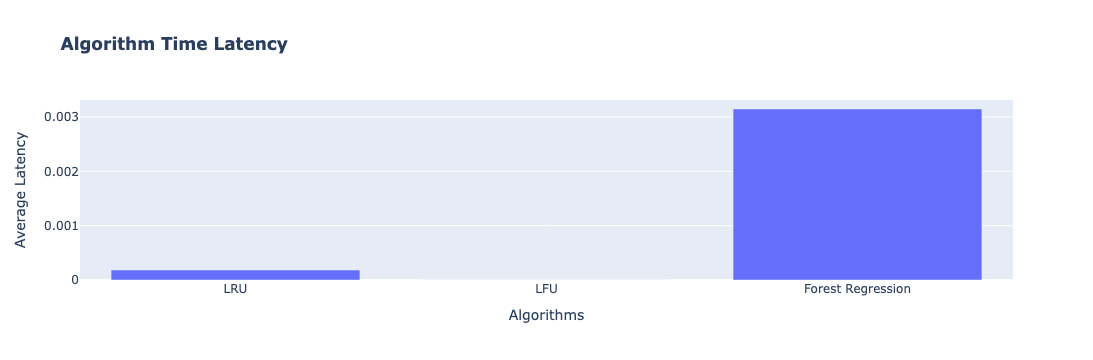

In [33]:
algorithms = ["LRU","LFU","Forest Regression"]
latency = [lru_latency_avg,lfu_latency_avg,ml_latency_avg]

fig = px.bar(x=algorithms,y=latency,labels={"x":"Algorithms","y":"Average Latency"},title="<b> Algorithm Time Latency <b>")
fig.show()


## 5.2 Observations — Latency Tradeoff

ML Cache (0.00854s) is significantly slower than LRU (0.00042s) and LFU 
(0.0000006s). This is the fundamental cost of intelligence — calling 
model.predict() on every eviction decision adds overhead that traditional 
algorithms avoid entirely. In latency-sensitive systems, this tradeoff 
must be evaluated carefully against the marginal hit rate gain.

## 5.3 Conclusion

LFU marginally outperforms ML (0.5985 vs 0.591) on this Zipfian workload 
because frequency alone captures most of the access pattern signal — making 
a 200-tree Random Forest largely redundant on stable, frequency-dominated traces.

However the latency tradeoff is that ML is 15,000x slower than 
LFU (0.00854s vs 0.0000006s) for a marginal hit rate gain. In latency-sensitive 
production systems, this cost is difficult to justify.

ML-based eviction becomes worthwhile on dynamic workloads with shifting 
popularity i.e. where historical frequency becomes an unreliable signal and 
recency + reuse distance give ML a genuine edge.

## IS LFU better than ML
Not universally. On a pure Zipf trace LFU marginally wins because frequency dominates the access pattern. But on dynamic workloads with shifting popularity, ML's recency feature gives it an advantage LFU doesn't have. The more interesting finding is the latency tradeoff — ML is 15,000x slower than LFU for a 1% hit rate difference, which matters a lot in production systems.

# END